<a href="https://colab.research.google.com/github/Kevantech/python-coursework/blob/main/Self_study_try_it_activity_6_1_Ranking_in_Python1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
cols = list(data.columns)
print(cols)

['Unnamed: 0', 'research_rank', 'student_staff_ratio_rank', 'num_students_rank', 'world_rank', 'university_name']


In [8]:
cols.remove('university_name')
cols.remove('world_rank')
cols.remove('Unnamed: 0')
print(cols)

['research_rank', 'student_staff_ratio_rank', 'num_students_rank']


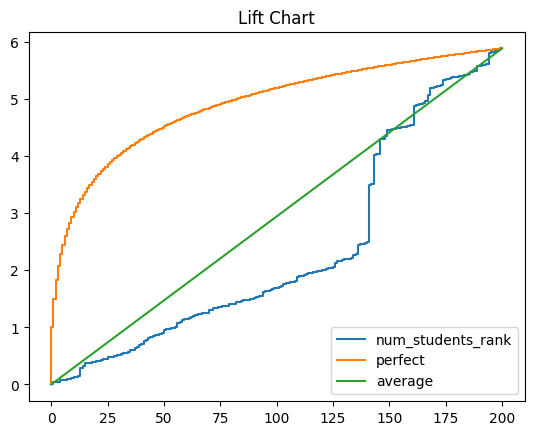

In [9]:
import matplotlib.pyplot as plt
import numpy as np

model1_df = data[['num_students_rank', 'world_rank']].copy()
model1_df = model1_df.sort_values(by='num_students_rank')

perf = model1_df.sort_values(by='world_rank')

model1_df['inv_world_rank'] = 1 / model1_df['world_rank']
perf['inv_world_rank'] = 1 / perf['world_rank']

model1_df['cumulative'] = model1_df['inv_world_rank'].cumsum()
perf['cumulative'] = perf['inv_world_rank'].cumsum()

cumulative = np.insert(model1_df['cumulative'].values, 0, 0)
cumulative_perf = np.insert(perf['cumulative'].values, 0, 0)

plt.step(range(len(model1_df)+1), cumulative, label='num_students_rank')
plt.step(range(len(perf)+1), cumulative_perf, label='perfect')

plt.plot([0, len(data)], [0, np.sum(1/data['world_rank'])], label='average')

plt.legend()
plt.title("Lift Chart")
plt.show()

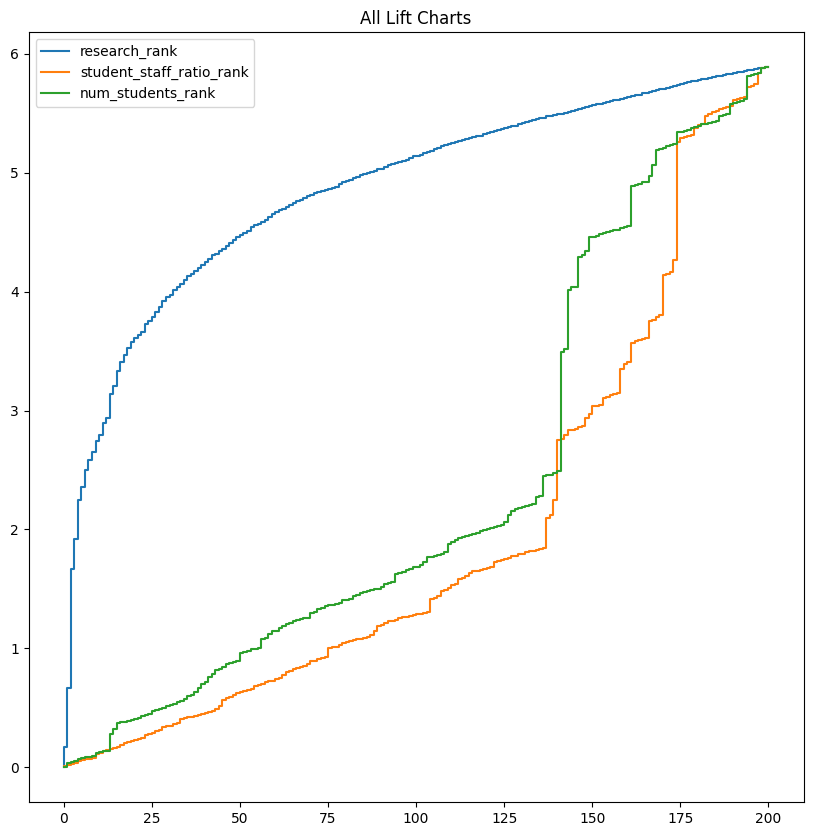

In [10]:
plt.figure(figsize=(10,10))

for model in cols:
    df = data[[model, 'world_rank']].copy()
    df = df.sort_values(by=model)

    df['inv'] = 1 / df['world_rank']
    df['cum'] = df['inv'].cumsum()

    cumulative = np.insert(df['cum'].values, 0, 0)
    plt.step(range(len(df)+1), cumulative, label=model)

plt.legend()
plt.title("All Lift Charts")
plt.show()

In [ ]:
The research_rank model performs best because its curve is closest to the perfect model.
The student_staff_ratio_rank performs moderately well.
The num_students_rank performs the worst as it stays closer to the average line.